In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns


import sys
sys.path.append("../..")
from src.utils import mark_repeated_columns
from src.plotting import plot_acf_pacf
from src.dynamicFPC import super_fun

# Configs
import plotly.io as pio
pio.templates.default = "plotly_dark"
pio.renderers.default = "notebook_connected"

In [2]:
def lag_matrix(x, L):
    df = pd.concat([x.shift(i) for i in range(0, L + 1)], axis=1)
    df.columns = [f"{x.name}_t-{i}" for i in range(0, L + 1)]
    return df.dropna()

In [3]:
LOG_VOLATILITY:bool = True # if false, doesn't apply log to realized volatility.
DHAT = 5 # number of the dimensions from dFPC to keep and work with

# Data

In [4]:
data_path = "../../data/processed/"
returns_path = ''.join([data_path, 'ibovespa_treated.xlsx'])
df_ibovespa = pd.read_excel(returns_path, index_col="time")#.loc[:,"r_t"]
df_ibovespa.head()

,2024-12-02,2024-12-03,2024-12-04,2024-12-05,2024-12-06,2024-12-09,2024-12-10,2024-12-11,2024-12-12,2024-12-13,...,2025-11-14,2025-11-17,2025-11-18,2025-11-19,2025-11-21,2025-11-24,2025-11-25,2025-11-26,2025-11-27,2025-11-28
time,,,,,,,,,,,,,,,,,,,,,
10:05:00,-0.002271,0.003372,0.001716,0.005538,0.000069,0.006429,0.002343,0.001918,-0.007582,-0.000413,...,-0.001522,0.000739,-0.000613,0.000306,-0.002021,-0.000810,0.001557,-0.001565,-0.000193,0.002906
10:10:00,-0.000582,0.002832,-0.000502,0.000739,0.000261,0.001891,0.000775,-0.001172,0.000216,-0.000432,...,0.000360,-0.000105,-0.000159,-0.000362,0.000092,0.001131,0.001170,0.000202,0.000556,0.000475
10:15:00,-0.001997,0.001091,0.000111,-0.000192,0.000407,-0.001392,-0.000477,-0.001526,0.000198,-0.001821,...,0.001121,-0.000284,0.003272,-0.001107,-0.001012,-0.000174,0.001002,0.001815,-0.000168,0.000973
10:20:00,-0.000037,-0.000505,-0.000327,-0.000580,-0.000436,-0.000405,0.001263,0.000676,-0.002667,0.001033,...,0.000449,0.000335,0.000853,0.000981,-0.000057,-0.000096,0.000832,0.001951,0.001060,-0.001004
10:25:00,0.000364,-0.001532,0.000429,-0.000426,-0.000162,-0.000130,0.000060,0.000818,-0.000970,0.000670,...,-0.000871,-0.000559,0.001030,-0.000749,-0.001194,0.001338,0.000128,0.001279,-0.000162,-0.000651


# Exploratory analysis

In [5]:
df_squared_returns = df_ibovespa**2
realized_volatility = df_squared_returns.sum(axis=0)
if LOG_VOLATILITY:
    realized_volatility = np.log(realized_volatility)
realized_volatility.name = "realized_volatility"
realized_volatility.index.name = "date"

In [6]:
fig = px.line(
    df_ibovespa,
    color_discrete_sequence=['#80ed99'],  
    title="Returns by tick")

fig.update_layout(
    legend_title_text='Curve'
)
fig.update_traces(opacity=.4)
fig.show()

In [7]:
fig = px.line(
    df_squared_returns,
    color_discrete_sequence=['#80ed99'],
    title="Squared returns"
    )

fig.update_layout(
    legend_title_text='Curve'
)
fig.update_traces(opacity=.4)
fig.update_layout(yaxis=dict(exponentformat='power'))
fig.show()

In [8]:
fig = px.line(
    realized_volatility,
    color_discrete_sequence=['#80ed99'],
    title="Log Realized volatility" if LOG_VOLATILITY else "Realized volatility"
    )

fig.update_layout(
    # legend_title_text='Curve',
    showlegend=False
)

fig.update_layout(yaxis=dict(exponentformat='power'))
fig.show()

In [9]:
#realized_volatility.to_excel("../../data/processed/ibovespa_realized_volatility.xlsx")

In [10]:

acf_values = sm.tsa.stattools.acf(realized_volatility, nlags=100)
n = len(realized_volatility)
conf_interval = 1.96 / np.sqrt(n)
significant_acf_lags = np.where(np.abs(acf_values[1:]) > conf_interval)[0] + 1
print("Significant ACF Lags:", significant_acf_lags)

pacf_values = sm.tsa.stattools.pacf(realized_volatility, nlags=100)
significant_pacf_lags = np.where(np.abs(pacf_values[1:]) > conf_interval)[0] + 1
print("Significant PACF Lags:", significant_pacf_lags)

Significant ACF Lags: [ 1  2  3  4  5  6  7 21 22 78]
Significant PACF Lags: [ 1  2  3 20 23 67 71 78 87 97]


In [11]:
# AUTOCORRELATION
title = f"Correlation analysis"
max_lag = np.hstack([significant_acf_lags,significant_pacf_lags]).max() + 5
plot_acf_pacf(
        realized_volatility, 
        title=title,
        nlags=max_lag
        )

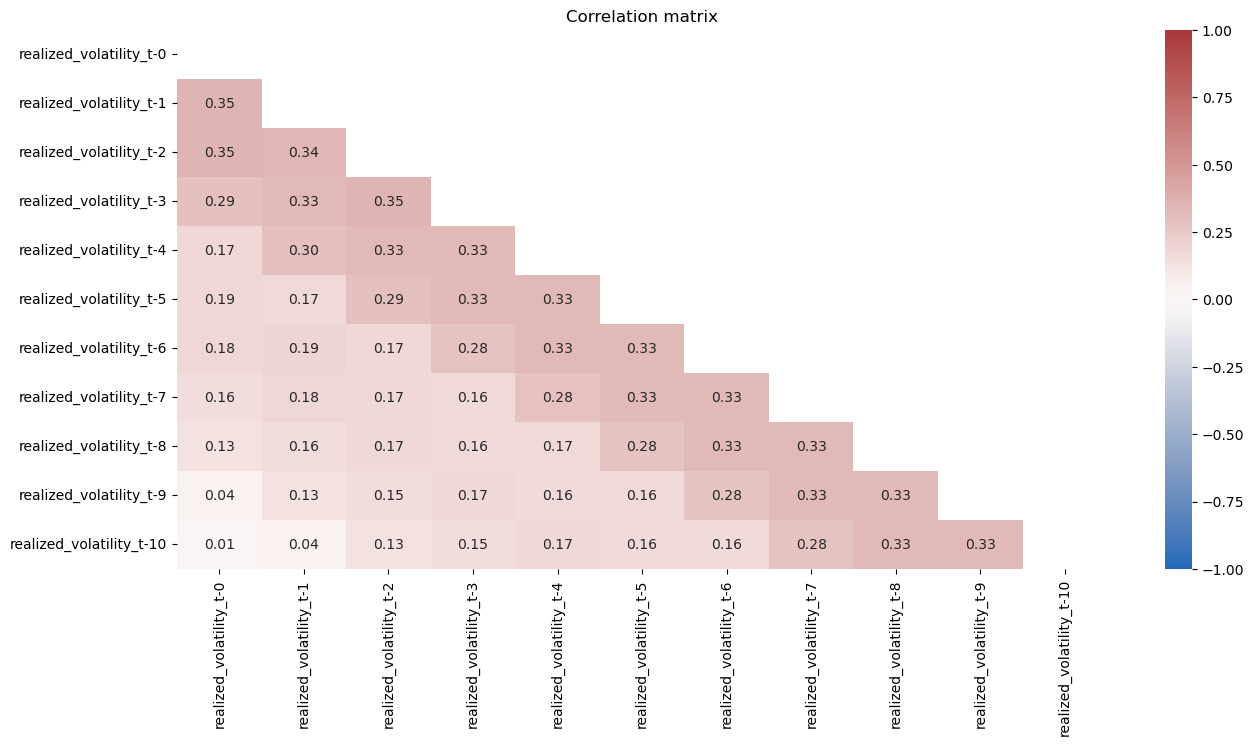

In [12]:
N_VOLATILITY_LAGS = 10
realized_volatility_lags = lag_matrix(realized_volatility,N_VOLATILITY_LAGS)

plt.figure(figsize=(15,7))
corr_matrix = realized_volatility_lags.corr(method="pearson")
matrix = np.triu(corr_matrix)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", cbar=True, mask=matrix, vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.show()


In [13]:
fig = px.scatter_matrix(
    realized_volatility_lags,
    width=1000,
    height=1000
    )
fig.update_traces(showlowerhalf=False)
fig.show()

In [14]:
fig = px.scatter(
    x=realized_volatility.shift(1),
    y=realized_volatility, 
    title="$(\hat{\zeta}_{t-1}, \hat{\zeta}_t)$",
    trendline="ols"
    )
fig.show()

# Scores

In [15]:
scores_path = "../../data/processed/dfpc_scores.xlsx"
df_scores = pd.read_excel(scores_path).set_index("index").iloc[:,:DHAT]

In [16]:
df_vol_scores = pd.concat([realized_volatility, df_scores], axis=1)
# Adds 1 lag
for eta in df_scores.columns:
    col_name = eta.replace("$","")
    df_vol_scores[f"{col_name}_t-1"] = df_vol_scores[eta].shift(1)
df_vol_scores.dropna(inplace=True)

corr_matrix = df_vol_scores.corr(method="pearson")
display(corr_matrix)

upper_indices = np.triu_indices_from(corr_matrix, k=1)
sorted_list = np.sort(np.abs(corr_matrix).values[upper_indices])[::-1].tolist()
print("Top absolute correlations: ", sorted_list)

,realized_volatility,$η_1$,$η_2$,$η_3$,$η_4$,$η_5$,η_1_t-1,η_2_t-1,η_3_t-1,η_4_t-1,η_5_t-1
realized_volatility,1.000000,-0.966898,-0.461058,-0.297063,-0.077770,0.025583,-0.401716,0.044494,0.004386,0.016518,-0.041730
$η_1$,-0.966898,1.000000,0.339682,0.173002,0.087627,-0.012509,0.459050,-0.039173,-0.058856,-0.015613,0.042446
$η_2$,-0.461058,0.339682,1.000000,-0.001617,-0.037374,-0.255716,0.074442,-0.040128,-0.008197,0.052355,0.039430
$η_3$,-0.297063,0.173002,-0.001617,1.000000,0.101985,0.387175,-0.106043,-0.127486,0.221593,-0.000425,0.058899
$η_4$,-0.077770,0.087627,-0.037374,0.101985,1.000000,0.337295,0.018136,0.086532,0.040148,-0.065358,-0.008043
$η_5$,0.025583,-0.012509,-0.255716,0.387175,0.337295,1.000000,-0.100381,-0.004457,0.077791,0.018499,0.036885
η_1_t-1,-0.401716,0.459050,0.074442,-0.106043,0.018136,-0.100381,1.000000,0.338992,0.169196,0.085172,-0.010902
η_2_t-1,0.044494,-0.039173,-0.040128,-0.127486,0.086532,-0.004457,0.338992,1.000000,0.003710,-0.033286,-0.256573
η_3_t-1,0.004386,-0.058856,-0.008197,0.221593,0.040148,0.077791,0.169196,0.003710,1.000000,0.107432,0.390471
η_4_t-1,0.016518,-0.015613,0.052355,-0.000425,-0.065358,0.018499,0.085172,-0.033286,0.107432,1.000000,0.339838


Top absolute correlations:  [0.9668976581164059, 0.46105776908734863, 0.45904990295362, 0.401716209259771, 0.3904712209976916, 0.3871747045713969, 0.3398377532433363, 0.33968209159429286, 0.33899167598419827, 0.3372953108076331, 0.29706341837250755, 0.2565727506971445, 0.25571627740764336, 0.22159286629623276, 0.1730021276359564, 0.16919570458803093, 0.12748609776650496, 0.10743202307905564, 0.10604291643643576, 0.10198502015713873, 0.10038114168332599, 0.08762727854344574, 0.08653150060978267, 0.08517167504674525, 0.07779086999625184, 0.07777045688431986, 0.07444159750371196, 0.06535807767981676, 0.058898873693358646, 0.05885629576187987, 0.052354501818185496, 0.04449368362035402, 0.04244576526694621, 0.04172992796755451, 0.04014801624967561, 0.04012833384851288, 0.039430375783813795, 0.03917295062350566, 0.037374080210863074, 0.03688451506858916, 0.03328601864218696, 0.025583194928395833, 0.018498837628659916, 0.018136130076556983, 0.016517932023606244, 0.015613219381086488, 0.012509

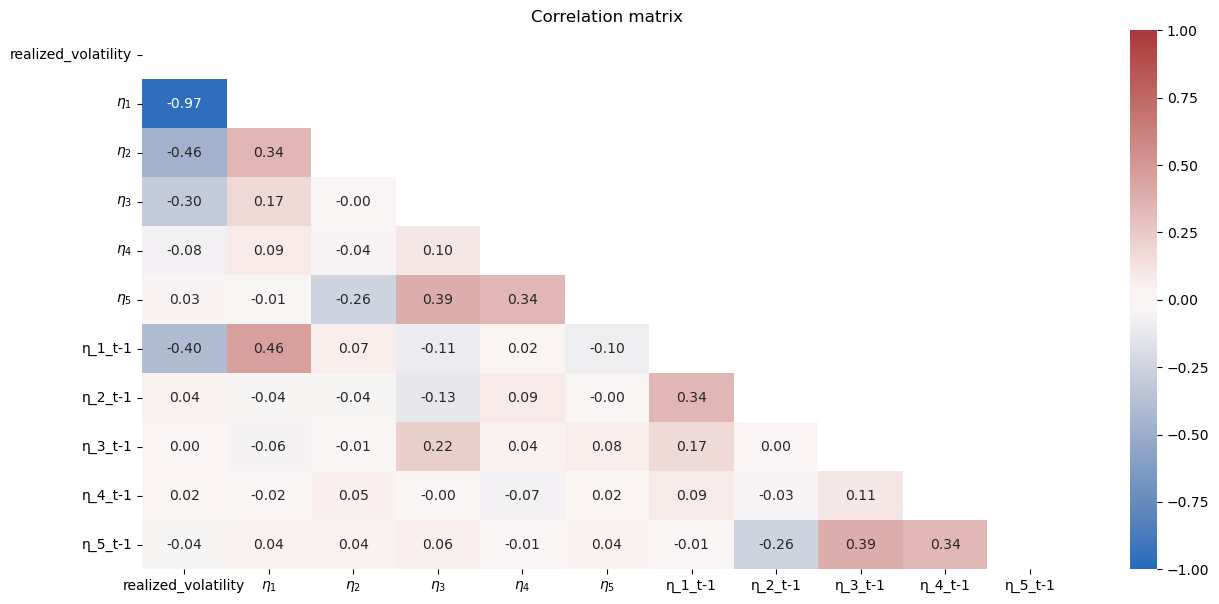

In [17]:
corr_matrix = df_vol_scores.corr()

plt.figure(figsize=(15,7))
matrix = np.triu(corr_matrix)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", cbar=True, mask=matrix, vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.show()

In [18]:
corr_matrix = corr_matrix.mask(np.eye(corr_matrix.shape[1], dtype=bool))
c = corr_matrix.values
# Flatten the matrix into a 1D array
flattened_array = np.abs(c).flatten()

# Sort the 1D array in-place (optional, you can also use np.sort())
flattened_array.sort()

# Convert the sorted NumPy array to a standard Python list
sorted_list = flattened_array.tolist()[::-1]

print(sorted_list)

[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 0.9668976581164059, 0.9668976581164059, 0.46105776908734863, 0.46105776908734863, 0.45904990295362, 0.45904990295362, 0.401716209259771, 0.401716209259771, 0.3904712209976916, 0.3904712209976916, 0.3871747045713969, 0.3871747045713969, 0.3398377532433363, 0.3398377532433363, 0.33968209159429286, 0.33968209159429286, 0.33899167598419827, 0.33899167598419827, 0.3372953108076331, 0.3372953108076331, 0.29706341837250755, 0.29706341837250755, 0.2565727506971445, 0.2565727506971445, 0.25571627740764336, 0.25571627740764336, 0.22159286629623276, 0.22159286629623276, 0.1730021276359564, 0.1730021276359564, 0.16919570458803093, 0.16919570458803093, 0.12748609776650496, 0.12748609776650496, 0.10743202307905564, 0.10743202307905564, 0.10604291643643576, 0.10604291643643576, 0.10198502015713873, 0.10198502015713873, 0.10038114168332599, 0.10038114168332599, 0.08762727854344574, 0.08762727854344574, 0.08653150060978267, 0.08653150060978267, 0.

In [19]:
fig = px.scatter_matrix(
    df_vol_scores,
    width=1000,
    height=1000
    )
fig.update_traces(showlowerhalf=False)
fig.show()

In [20]:
fig = px.scatter(
    x=df_scores.iloc[:,0].shift(1),
    y=realized_volatility, 
    title="$(\hat{\zeta}_{t-1}, \hat{\zeta}_t)$",
    trendline="ols"
    )
fig.show()

## LQdFPC vs dFPC

Log-Quantile Density dFPC vs ($L^2$) dFPC [Horta & Ziegelmann, 2018]

In [21]:
df_scores_comparison = pd.read_excel("../../data/processed/scores_LQdFPC_vs_dFPC.xlsx", index_col="date")
df_scores_comparison.head()

,eta_LQdFPC,eta_dFPC
date,,
2024-12-02,-2.006633,-328.602200
2024-12-03,-1.698631,-97.698391
2024-12-04,0.750473,-80.093101
2024-12-05,2.214950,146.773494
2024-12-06,1.975190,93.865445


In [22]:
fig = px.scatter(
    x=df_scores_comparison.iloc[:,0],
    y=df_scores_comparison.iloc[:,1],
    title="$(\hat{\eta}_{t1}^{LQD}, \hat{\eta}_{t1}^{D})$",
    trendline='ols'
    )
fig.add_vline(-4)
fig.add_vline(3)
fig.show()

In [23]:
fig = px.scatter(
    x=df_scores_comparison.loc[:, 'eta_LQdFPC'],
    y=realized_volatility, 
    title="$(\hat{\eta}_{t1}^{LQ}, \hat{\zeta}_t)$",
    trendline="ols"
    )

# fig.add_vline(-4)
fig.add_vline(3)
fig.show()

In [24]:
fig = px.scatter(
    x=df_scores_comparison.loc[:, 'eta_dFPC'],
    y=realized_volatility, 
    title="$(\hat{\eta}_{t1}^{D}, \hat{\zeta}_t)$",
    trendline="ols" #vs ols, lowess, ewm,
    )

fig.add_vline(250)
fig.show()

### OLS for $\log{\zeta_t} = \beta_0 + \beta_1 \eta_t1$


In [25]:

ols = sm.OLS(realized_volatility.values, sm.add_constant(df_scores_comparison.iloc[:,0])).fit()
residuals_mvs = ols.resid

ols = sm.OLS(realized_volatility.values, sm.add_constant(df_scores_comparison.iloc[:,1])).fit()
residuals_horta = ols.resid

df_residuals_mvs_h = pd.concat([pd.Series(residuals_mvs), residuals_horta], axis=1)
# df_residuals_mvs_h.columns = df_scores_comparison.columns
df_residuals_mvs_h.columns = ['$\hat{\eta}_{t1}^{LQD}$', '$\hat{\eta}_{t1}^{D}$']

fig = px.line(
    df_residuals_mvs_h,
    title="Residuals from OLS")

fig.update_layout(
    hovermode="x unified"
)

fig.show()

In [26]:
px.histogram(df_residuals_mvs_h, marginal="violin", title="Residuals from OLS")